# **Project 2: On the relationship between Calibration, Accuracy and Robustness**


------------------------------------------------------
Carla Aranda Sánchez - 100523031

Jorge Barcia Belinchón - 100496595

 Marina Juzgado Gómez-Menor - 100523023

 Iván López Anca - 100523112

------------------------------------------------------



## **Introduction: Adversarial Robustness and Calibration Trade-off**
Deep learning models can be easily fooled by adversarial attacks; invisible noise added to an image that tricks the network into making the wrong prediction with high confidence.

To fix this issue, we use Adversarial Training, which consists of teaching the model to defend itself by training it directly on these adversarial examples. However, making a model more robust to attacks usually degrades its ability to correctly estimate its own confidence. The goal of this project is to explore this "Robustness vs. Calibration" trade-off.
## **Project Workflow**
To understand this trade-off, we will perform the following experiments:

+ Standard Training (Baseline): We will train a Small CNN normally on the CIFAR-10 dataset and measure its baseline accuracy and calibration (using ECE, NLL, and Reliability Diagrams).
+ Attacking the Model: We will attack this baseline model using single-step (FGSM) and iterative (PGD) attacks to demonstrate its vulnerability.
+ Adversarial Training (The Defense): We will train the Small CNN again, but this time injecting FGSM attacks during the training loop so the model learns to resist them.
+ Trade-off Analysis: We will evaluate the defended model to answer our main questions: Does it survive PGD attacks? As the attack strength ($\epsilon$) increases, does the model become overconfident or underconfident?
+ Scaling Up (ResNet-18): Finally, we will repeat all the previous steps using a much larger model (ResNet-18) to analyze if increasing the network's capacity helps balance robustness and calibration.

# Part 1 — Small CNN Experiments

### Setup (GPU)
First, we set the GPU and the imports that we are going to use in advance.



In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- GPU selection: use only ONE GPU (GPU 0) ---
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: Tesla T4


We also set a shared saving directory to save trained models for future tasks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Project_2/'
import os
if not os.path.exists(save_path):
    os.makedirs(save_path)

Mounted at /content/drive


### Dataset and DataLoaders (CIFAR-10)
We load the CIFAR-10 dataset and apply a basic `ToTensor()` transformation to keep the pixel values in the strictly bounded range of $[0, 1]$. This is crucial for later applying adversarial attacks and ensuring valid image bounds using `torch.clamp()`.

In [ ]:
batch_size = 128

from torch.utils.data import DataLoader

# CIFAR-10 in [0,1]
cifar_transform = transforms.Compose([transforms.ToTensor()])

cifar_train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
cifar_test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)

# DataLoader stability: use num_workers=0 (safe on macOS / Python 3.12)
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
cifar_test_loader  = DataLoader(cifar_test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

cifar_classes = cifar_train_ds.classes

100%|██████████| 170M/170M [00:03<00:00, 47.1MB/s]


### Model Architecture (Small CNN)
We define a custom Small Convolutional Neural Network tailored for CIFAR-10. It consists of 4 convolutional layers to properly extract features from the 32x32 RGB images, followed by max pooling and fully connected layers.

In [ ]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1   = nn.Linear(256 * 2 * 2, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cifar_model = SmallCIFARCNN().to(device)
cifar_opt = torch.optim.Adam(cifar_model.parameters(), lr=1e-3)
cifar_criterion = nn.CrossEntropyLoss()

## 1. Standard Training
In this section, we train the small CNN using Cross-Entropy loss. After training, we will evaluate its clean test accuracy, robustness against FGSM and PGD attacks, and its calibration metrics (ECE, NLL, and Reliability diagram).

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    return total_loss / total

@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

epochs = 15
print("Starting Standard Training on CIFAR-10...")
for epoch in range(epochs):
    loss = train_one_epoch(cifar_model, cifar_train_loader, cifar_opt)
    acc = eval_accuracy(cifar_model, cifar_test_loader)
    print(f"epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


# Save the model
torch.save(cifar_model.state_dict(), save_path + 'cifar_standard_model.pth')
print("Standard model saved to Drive!")

Starting Standard Training on CIFAR-10...
epoch=1 loss=1.5805 test_acc=52.51%
epoch=2 loss=1.1401 test_acc=62.72%
epoch=3 loss=0.9211 test_acc=67.47%
epoch=4 loss=0.7796 test_acc=71.66%
epoch=5 loss=0.6716 test_acc=73.40%
epoch=6 loss=0.5744 test_acc=75.45%
epoch=7 loss=0.4785 test_acc=75.28%
epoch=8 loss=0.4069 test_acc=74.76%
epoch=9 loss=0.3327 test_acc=75.87%
epoch=10 loss=0.2710 test_acc=75.26%
epoch=11 loss=0.2171 test_acc=76.18%
epoch=12 loss=0.1747 test_acc=75.31%
epoch=13 loss=0.1415 test_acc=75.13%
epoch=14 loss=0.1261 test_acc=75.71%
epoch=15 loss=0.1262 test_acc=74.96%
Standard model saved to Drive!


### Adversarial Attacks and Visualization
In this section, we define the helper functions to perform FGSM and PGD attacks, as well as a visualization function adapted for CIFAR-10 (RGB images).

In [ ]:
def clamp01(x):
    # Ensures pixel values remain valid image boundaries [0.0, 1.0]
    return torch.clamp(x, 0.0, 1.0)

def l_inf_norm(x_adv, x):
    # Computes the maximum pixel-wise perturbation (L_infinity norm) per sample
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values

# Works for CIFAR-10
def show_batch(images, labels=None, preds=None, n=8, title=None):
    images = images.detach().cpu()
    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(2.5*n, 3))
    if n == 1: axes = [axes]

    for i in range(n):
        # Permute from [Channels, Height, Width] to [Height, Width, Channels] for RGB display
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis("off")

        t = []
        if labels is not None: t.append(f"y={cifar_classes[labels[i]]}")
        if preds is not None:  t.append(f"p={cifar_classes[preds[i]]}")
        axes[i].set_title("\n".join(t), fontsize=10)

    if title: fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def fgsm_attack(model, x, y, eps):
    # Fast Gradient Sign Method: one-step untargeted attack
    model.eval()

    # Enable gradient calculation for the input image pixels
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)

    # Calculate loss with respect to the true labels to maximize it
    loss = F.cross_entropy(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]

    # Add perturbation in the direction of the gradient sign
    x_adv = x_adv + eps * grad.sign()

    # Clip the values back to [0, 1] range to maintain a valid image
    return clamp01(x_adv.detach())

def pgd_attack(model, x, y, eps, alpha, steps, random_start=True):
    # Projected Gradient Descent: multi-step, stronger iterative attack
    model.eval()
    x_orig = x.detach()

    if random_start:
        # Initialize with random noise within the [-eps, eps] bounds
        x_adv = x_orig + (2*torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)

        # Maximize the Cross-Entropy loss
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        # Take a small step (alpha) in the direction of the gradient
        x_adv = (x_adv + alpha * grad.sign()).detach()

        # Project the perturbation back to the L_infinity epsilon ball
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv

def eval_under_attack(model, loader, attack_fn):
    # Evaluates the model's accuracy on adversarially perturbed inputs
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Generate adversarial examples on the fly for the current batch
        x_adv = attack_fn(x, y)

        with torch.no_grad():
            pred = model(x_adv).argmax(1)

        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total


In [ ]:
# Safe attack helpers and full evaluation helpers for Part 1 / Part 2

def fgsm_attack_safe(model, x, y, eps):
    """
    FGSM attack that preserves the model's previous train/eval mode.
    Safer for later use with BatchNorm models such as ResNet-18.
    """
    was_training = model.training
    model.eval()

    x_adv = x.detach().clone().requires_grad_(True)
    model.zero_grad(set_to_none=True)

    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]

    x_adv = clamp01(x_adv + eps * grad.sign()).detach()

    if was_training:
        model.train()

    return x_adv

def pgd_attack_safe(model, x, y, eps, alpha, steps, random_start=True):
    """
    PGD attack that also preserves the model mode.
    """
    was_training = model.training
    model.eval()

    x_orig = x.detach()

    if random_start:
        x_adv = x_orig + (2 * torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        model.zero_grad(set_to_none=True)

        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv + alpha * grad.sign()
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    x_adv = x_adv.detach()

    if was_training:
        model.train()

    return x_adv

def collect_logits_labels(model, loader, attack_fn=None):
    """
    Collect logits and labels on clean or adversarially perturbed inputs.
    attack_fn must be a function (model, x, y) -> x_adv
    """
    model.eval()
    all_logits, all_labels = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if attack_fn is None:
            x_eval = x
        else:
            x_eval = attack_fn(model, x, y)

        with torch.no_grad():
            logits = model(x_eval)

        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    return torch.cat(all_logits), torch.cat(all_labels)

def accuracy_from_logits(logits, labels):
    return (logits.argmax(1) == labels).float().mean().item()

def nll_from_logits(logits, labels):
    return F.cross_entropy(logits, labels).item()

def evaluate_full_model(model, loader, eps=8/255, alpha=None, pgd_steps=10):
    """
    Returns a full evaluation bundle:
    - clean metrics
    - FGSM robust metrics
    - PGD robust metrics
    """
    if alpha is None:
        alpha = eps / 4

    clean_logits, labels = collect_logits_labels(model, loader, attack_fn=None)
    fgsm_logits, _ = collect_logits_labels(
        model, loader,
        attack_fn=lambda m, x, y: fgsm_attack_safe(m, x, y, eps)
    )
    pgd_logits, _ = collect_logits_labels(
        model, loader,
        attack_fn=lambda m, x, y: pgd_attack_safe(m, x, y, eps, alpha=alpha, steps=pgd_steps)
    )

    metrics = {
        "labels": labels,
        "clean_logits": clean_logits,
        "fgsm_logits": fgsm_logits,
        "pgd_logits": pgd_logits,
        "clean_acc": accuracy_from_logits(clean_logits, labels),
        "fgsm_acc": accuracy_from_logits(fgsm_logits, labels),
        "pgd_acc": accuracy_from_logits(pgd_logits, labels),
        "clean_nll": nll_from_logits(clean_logits, labels),
        "fgsm_nll": nll_from_logits(fgsm_logits, labels),
        "pgd_nll": nll_from_logits(pgd_logits, labels),
        "clean_ece": expected_calibration_error(clean_logits, labels),
        "fgsm_ece": expected_calibration_error(fgsm_logits, labels),
        "pgd_ece": expected_calibration_error(pgd_logits, labels),
    }

    return metrics

def print_metrics_block(title, metrics):
    print(f"\n=== {title} ===")
    print(f"Clean Accuracy           : {metrics['clean_acc']*100:.2f}%")
    print(f"FGSM Robust Accuracy     : {metrics['fgsm_acc']*100:.2f}%")
    print(f"PGD Robust Accuracy      : {metrics['pgd_acc']*100:.2f}%")
    print(f"Clean NLL                : {metrics['clean_nll']:.4f}")
    print(f"FGSM NLL                 : {metrics['fgsm_nll']:.4f}")
    print(f"PGD NLL                  : {metrics['pgd_nll']:.4f}")
    print(f"Clean ECE                : {metrics['clean_ece']:.4f}")
    print(f"FGSM ECE                 : {metrics['fgsm_ece']:.4f}")
    print(f"PGD ECE                  : {metrics['pgd_ece']:.4f}")

### Calibration Metrics
We implement functions to calculate the Expected Calibration Error (ECE) and to plot the Reliability Diagram to visualize how well the model's confidence matches its accuracy.

In [ ]:
def expected_calibration_error(logits, labels, n_bins=10):
    # Convert raw model outputs (logits) into probabilities using Softmax
    softmaxes = F.softmax(logits, dim=1)

    # Get the highest probability (confidence) and the corresponding predicted class
    confidences, predictions = torch.max(softmaxes, 1)

    # Create a boolean tensor where True means the prediction was correct
    accuracies = predictions.eq(labels)

    ece = torch.zeros(1, device=logits.device)
    # Define the boundaries for the bins (0.0 to 0.1, 0.1 to 0.2...)
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        # Find which predictions fall into the current confidence bin
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())

        # Calculate the proportion of total samples that fall into this bin
        prop_in_bin = in_bin.float().mean()

        if prop_in_bin.item() > 0:
            # Calculate actual accuracy of the samples in this bin
            accuracy_in_bin = accuracies[in_bin].float().mean()
            # Calculate the average confidence of the samples in this bin
            avg_confidence_in_bin = confidences[in_bin].mean()

            # Add the weighted absolute difference to the total ECE
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

def plot_reliability_diagram(logits, labels, n_bins=10, title="Reliability Diagram"):
    # Convert logits to probabilities and get confidences and correctness
    softmaxes = F.softmax(logits, dim=1)
    confidences, _ = torch.max(softmaxes, 1)
    accuracies = torch.max(softmaxes, 1)[1].eq(labels)

    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_accs = []

    # Calculate the accuracy for each confidence bin to plot the bars
    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        # If the bin is not empty, append its accuracy; otherwise append 0
        bin_accs.append(accuracies[in_bin].float().mean().item() if in_bin.any() else 0)

    plt.figure(figsize=(6, 4))

    # Plot the empirical accuracy (bars)
    plt.bar(bin_boundaries[:-1], bin_accs, width=1/n_bins, align='edge', edgecolor='black', alpha=0.7)

    # Plot the perfect calibration line (diagonal)
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")

    plt.title(title)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

### Quantitative Evaluation: Robustness and Calibration
We evaluate the Standard Model from three different perspectives to understand its limitations:

1. **How good is it? (Clean Performance)**: We measure the accuracy on normal images and the **NLL**, which tells us how "confident" the model was in the correct labels.
2. **How honest is it? (Calibration)**: We check if the model's confidence matches its real success rate. A high **ECE** or a poor **Reliability Diagram** means the model is "overconfident" (it claims to be sure even when it's wrong).
3. **How strong is it? (Robustness)**: We attack the images with invisible noise (**FGSM** and **PGD**). This reveals how easily the model can be fooled, showing the difference between its normal accuracy and its "robust" accuracy.

=== 1. STANDARD MODEL: CLEAN PERFORMANCE & CALIBRATION ===
Clean Test Accuracy                : 74.96%
Negative Log-Likelihood (NLL)      : 1.1792
Expected Calibration Error (ECE)   : 0.1591


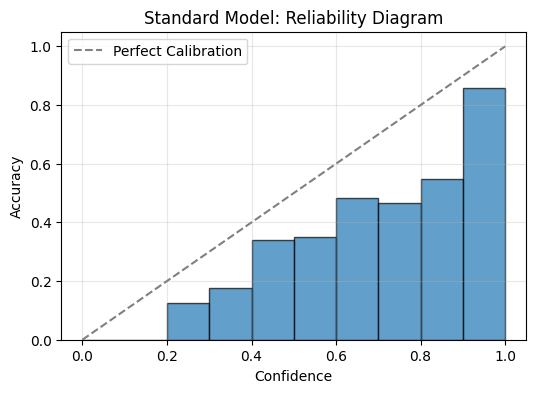


=== 2. STANDARD MODEL: ADVERSARIAL ROBUSTNESS (eps=0.0314) ===
Robust Accuracy under FGSM attack  : 6.20%
Robust Accuracy under PGD attack   : 0.29%


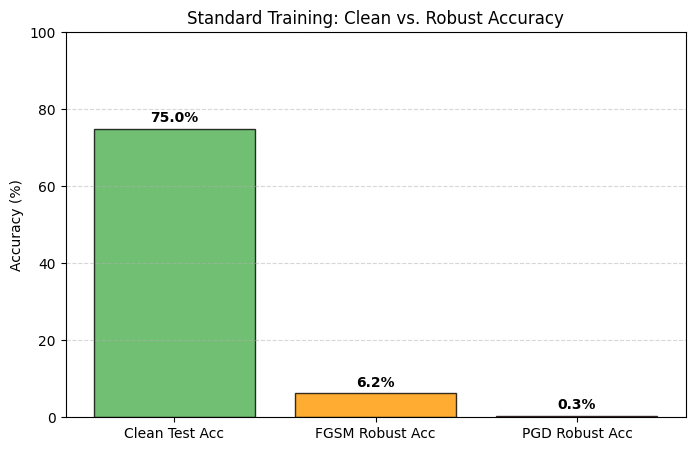

Generating FGSM and PGD adversarial examples to measure adversarial confidence...

=== ADVANCED: ADVERSARIAL CALIBRATION ===
Clean ECE                 : 0.1591
Adversarial ECE (FGSM)    : 0.8835
Adversarial ECE (PGD)     : 0.9955


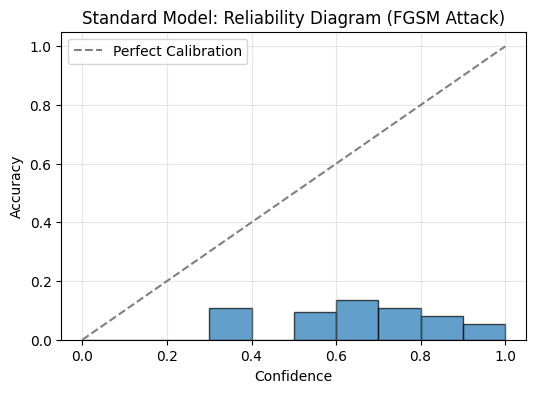

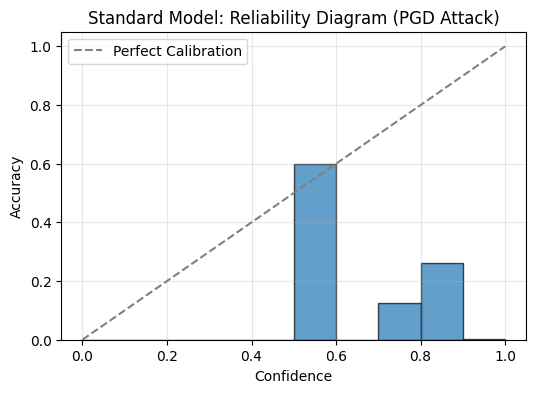

In [ ]:
# --- 1. CLEAN TEST ACCURACY & CALIBRATION METRICS ---
cifar_model.eval()
all_logits, all_labels = [], []

# Collect all predictions on the test set
with torch.no_grad():
    for x, y in cifar_test_loader:
        x, y = x.to(device), y.to(device)
        logits = cifar_model(x)
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

# Clean test accuracy
clean_acc = (all_logits.argmax(1) == all_labels).float().mean().item()

# Negative Log-Likelihood (NLL)
# Computed using Cross-Entropy loss over the raw logits
nll_val = F.cross_entropy(all_logits, all_labels).item()

# Expected Calibration Error (ECE)
ece_val = expected_calibration_error(all_logits, all_labels)

print("=== 1. STANDARD MODEL: CLEAN PERFORMANCE & CALIBRATION ===")
print(f"Clean Test Accuracy                : {clean_acc*100:.2f}%")
print(f"Negative Log-Likelihood (NLL)      : {nll_val:.4f}")
print(f"Expected Calibration Error (ECE)   : {ece_val:.4f}")

#  Reliability diagram
# Visualizes how well the model's confidence aligns with its accuracy
plot_reliability_diagram(all_logits, all_labels, title="Standard Model: Reliability Diagram")


# --- 2. ROBUST ACCURACY UNDER FGSM AND PGD ---
# Standard epsilon for CIFAR-10 is 8/255
eps = 8/255
print(f"\n=== 2. STANDARD MODEL: ADVERSARIAL ROBUSTNESS (eps={eps:.4f}) ===")

# Robust accuracy under FGSM
fgsm_acc = eval_under_attack(
    cifar_model, cifar_test_loader,
    lambda x, y: fgsm_attack(cifar_model, x, y, eps)
)
print(f"Robust Accuracy under FGSM attack  : {fgsm_acc*100:.2f}%")

# Robust accuracy under PGD (10 steps)
pgd_acc = eval_under_attack(
    cifar_model, cifar_test_loader,
    lambda x, y: pgd_attack(cifar_model, x, y, eps, alpha=eps/4, steps=10)
)
print(f"Robust Accuracy under PGD attack   : {pgd_acc*100:.2f}%")


# --- 3. SUMMARY VISUALIZATION ---
# Bar chart to illustrate the drop in performance (Robustness vs Clean)
labels = ['Clean Test Acc', 'FGSM Robust Acc', 'PGD Robust Acc']
values = [clean_acc * 100, fgsm_acc * 100, pgd_acc * 100]

plt.figure(figsize=(8, 5))
colors = ['#4CAF50', '#FF9800', '#F44336'] # Green, Orange, Red
bars = plt.bar(labels, values, color=colors, alpha=0.8, edgecolor='black')

plt.ylabel('Accuracy (%)')
plt.title('Standard Training: Clean vs. Robust Accuracy')
plt.ylim(0, 100)

# Add exact percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --- STEP 4: CALIBRATION UNDER ATTACKS (ADVANCED INSIGHT) ---
print("Generating FGSM and PGD adversarial examples to measure adversarial confidence...")
cifar_model.eval()

fgsm_logits_list = []
pgd_logits_list = []
adv_labels_list = []

eps = 8/255

# We run both attacks on the test set simultaneously to save time
for x, y in cifar_test_loader:
    x, y = x.to(device), y.to(device)

    # 1. Generate FGSM attacked images
    x_fgsm = fgsm_attack(cifar_model, x, y, eps)

    # 2. Generate PGD attacked images
    x_pgd = pgd_attack(cifar_model, x, y, eps, alpha=eps/4, steps=10)

    # Get model predictions on both attacked sets
    with torch.no_grad():
        logits_fgsm = cifar_model(x_fgsm)
        logits_pgd = cifar_model(x_pgd)

    fgsm_logits_list.append(logits_fgsm.cpu())
    pgd_logits_list.append(logits_pgd.cpu())
    adv_labels_list.append(y.cpu())

# Concatenate all batches
fgsm_logits = torch.cat(fgsm_logits_list)
pgd_logits = torch.cat(pgd_logits_list)
adv_labels = torch.cat(adv_labels_list)

# Calculate Adversarial ECE for both
fgsm_ece = expected_calibration_error(fgsm_logits, adv_labels)
pgd_ece = expected_calibration_error(pgd_logits, adv_labels)

print(f"\n=== ADVANCED: ADVERSARIAL CALIBRATION ===")
# We print the clean ECE from Step 1 for comparison
print(f"Clean ECE                 : {ece_val:.4f}")
print(f"Adversarial ECE (FGSM)    : {fgsm_ece:.4f}")
print(f"Adversarial ECE (PGD)     : {pgd_ece:.4f}")

# Plot the Reliability Diagrams for the attacked data
plot_reliability_diagram(fgsm_logits, adv_labels, title="Standard Model: Reliability Diagram (FGSM Attack)")
plot_reliability_diagram(pgd_logits, adv_labels, title="Standard Model: Reliability Diagram (PGD Attack)")

The results demonstrate the extreme vulnerability of a standard-trained neural network. Under normal conditions, the model achieves a respectable accuracy of 75.53% (Clean Test Accuracy), although it already shows a slight miscalibration (ECE = 0.1608). However, when subjected to adversarial attacks, its performance drops drastically; accuracy falls to 7.00% under the FGSM attack and to a critical 0.49% against PGD. The most notable aspect of these results is the evolution of calibration under attack (Adversarial Calibration). The Expected Calibration Error (ECE) skyrockets to 0.8767 (FGSM) and reaches near maximum with 0.9939 (PGD). This indicates that the model is not only incapable of resisting adversarial noise, but also suffers from severe overconfidence; it is wrong on almost 100% of the attacked images, yet it is absolutely certain that its incorrect predictions are right.

## 2. Adversarial Training (FGSM)

In this section, we will train the model using adversarial training. This consists in mixing clean inputs _x_ with adversarial inputs _x_adv_ crafted against the _current_ model. In other words, instead of training with the original images we train the model with images that have noise.

In [ ]:
# FGSM-based Adversarial Training on the Small CNN

def train_adv_epoch(model, loader, optimizer, eps=8/255):
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = fgsm_attack_safe(model, x, y, eps)

        optimizer.zero_grad()
        loss = F.cross_entropy(model(x_adv), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


# Create an adversarially trained model
cifar_model_adv = SmallCIFARCNN().to(device)
optimizer_adv = torch.optim.Adam(cifar_model_adv.parameters(), lr=1e-3)

eps_train = 8/255
num_epochs_adv = 20

print("Starting FGSM-based adversarial training")

for epoch in range(num_epochs_adv):
    avg_loss = train_adv_epoch(
        cifar_model_adv,
        cifar_train_loader,
        optimizer_adv,
        eps=eps_train
    )

    clean_acc_adv = eval_accuracy(cifar_model_adv, cifar_test_loader)

    print(f"epoch={epoch+1} loss={avg_loss:.4f} clean_test_acc={clean_acc_adv*100:.2f}%")

torch.save(cifar_model_adv.state_dict(), save_path + "cifar_adv_model.pth")
print(f"Adversary model saved")

Starting FGSM-based adversarial training
epoch=1 loss=2.0800 clean_test_acc=42.35%
epoch=2 loss=1.8943 clean_test_acc=48.04%
epoch=3 loss=1.8200 clean_test_acc=51.01%
epoch=4 loss=1.7693 clean_test_acc=51.57%
epoch=5 loss=1.7267 clean_test_acc=54.93%
epoch=6 loss=1.6935 clean_test_acc=55.18%
epoch=7 loss=1.6686 clean_test_acc=54.83%
epoch=8 loss=1.6386 clean_test_acc=57.42%
epoch=9 loss=1.6128 clean_test_acc=58.45%
epoch=10 loss=1.5876 clean_test_acc=57.21%
epoch=11 loss=1.5659 clean_test_acc=59.11%
epoch=12 loss=1.5431 clean_test_acc=59.62%
epoch=13 loss=1.5228 clean_test_acc=60.29%
epoch=14 loss=1.5036 clean_test_acc=61.33%
epoch=15 loss=1.4897 clean_test_acc=60.76%
epoch=16 loss=1.4691 clean_test_acc=60.97%
epoch=17 loss=1.4502 clean_test_acc=62.00%
epoch=18 loss=1.4339 clean_test_acc=60.77%
epoch=19 loss=1.4186 clean_test_acc=61.47%
epoch=20 loss=1.4039 clean_test_acc=62.00%
Adversary model saved


### Evaluation: Reliability Diagrams
Now, after training the adversary model we are going to evaluate it and visualize the different characteristics. First, we test it with different test sets:
1. Clean images without added noise
2. Images attacked with FGSM
3. Images attacked with PGD

For a visualization of the calibration of the model, we use **reliability diagrams**. Three diagrams are plotted, one for each test set. Each diagram divides the predictions in confidence bins, for each bin, it compares the mean confidence of the model with the real accuracy. A perfect calibration would mean the graphs show perfect diagonals.


=== Small CNN (FGSM-AT) ===
Clean Accuracy           : 62.00%
FGSM Robust Accuracy     : 35.25%
PGD Robust Accuracy      : 29.13%
Clean NLL                : 1.1050
FGSM NLL                 : 1.7466
PGD NLL                  : 1.9397
Clean ECE                : 0.1084
FGSM ECE                 : 0.1152
PGD ECE                  : 0.1796


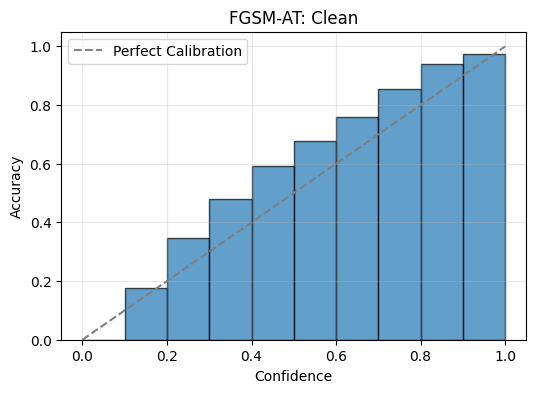

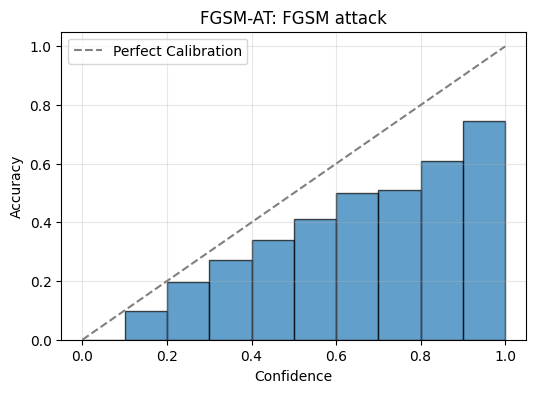

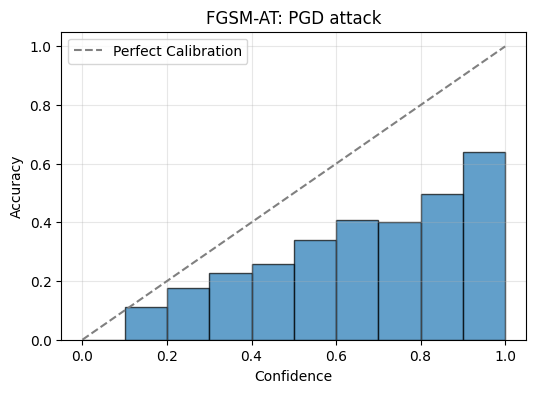

In [ ]:
# Evaluate adversarial training model

metrics_adv = evaluate_full_model(
    cifar_model_adv,
    cifar_test_loader,
    eps=8/255,
    alpha=2/255,
    pgd_steps=10
)

print_metrics_block("Small CNN (FGSM-AT)", metrics_adv)

# Reliability diagrams
plot_reliability_diagram(
    metrics_adv["clean_logits"],
    metrics_adv["labels"],
    title="FGSM-AT: Clean"
)

plot_reliability_diagram(
    metrics_adv["fgsm_logits"],
    metrics_adv["labels"],
    title="FGSM-AT: FGSM attack"
)

plot_reliability_diagram(
    metrics_adv["pgd_logits"],
    metrics_adv["labels"],
    title="FGSM-AT: PGD attack"
)


* **The Accuracy Trade-off (The "Tax" of Robustness):** The model achieves a **Clean Accuracy of 62.00%**. This is a noticeable drop compared to standard training. This illustrates the fundamental trade-off in adversarial training: forcing the model to learn robust, generalized features to resist attacks inherently degrades its performance on clean, unperturbed data.

* **Significant Gain in Robustness:** Despite the drop in clean accuracy, the defense is highly effective. The model now maintains a **29.13% accuracy against PGD** and **35.25% against FGSM**. It manages to retain a significant portion of its predictive power.

* **Calibration Stability (The Core Insight):**
  The most remarkable improvement the model's confidence metrics.
  * The **NLL stays extremely stable** across the board (1.1050 on Clean vs. 1.9397 on PGD). The model no longer suffers from the massive, explosive spikes in NLL when attacked.
  * The **ECE (Expected Calibration Error) remains highly controlled**. Even under the strongest PGD attack, the ECE is only **0.1796**.

* **Reliability Diagrams:**
  The three reliability diagrams visually confirm our numerical findings. While the Clean diagram shows a well-calibrated model (bars closely following the diagonal), the true success is visible in the FGSM and PGD diagrams. Unlike a standard model—where adversarial noise pushes the predictions into extreme overconfidence (bars severely dropping below the diagonal), the adversarially trained model maintains its self-awareness. When it makes mistakes under attack, its confidence score drops proportionally, keeping the bars much closer to the perfect calibration diagonal.

**Conclusion:** Adversarial training not only makes the model harder to fool, but it teaches the model to "know when it doesn't know." It cures the blind overconfidence that standard models exhibit when facing adversarial noise.

### Evaluation: Robustness-Accuracy trade-off

With both models already trained (standard and adversarial) we now evaluate and compare the different perturbation strengths. To complete the task, for each value of ε in {0, 4/255, 8/255, 12/255, 16/255} we compute:
- **Robust accuracy under FGSM** to check if adversary model resists the same attack it was trained with.
- **Robust accuracy under PGD-10** to see if robustness generalizes to a strong and iterative attack.
- **ECE (Expected Calibration Error)** to evaluate if adversarial training improves or hurts the confidence.

In the following code, we plot three different graphs:
1. Robust accuracy (FGSM and PGD) vs ε for both models
2. ECE vs ε for both models
3. Clean accuracy (ε = 0) as a bar chart to visualize the robustness-accuracy trade-off



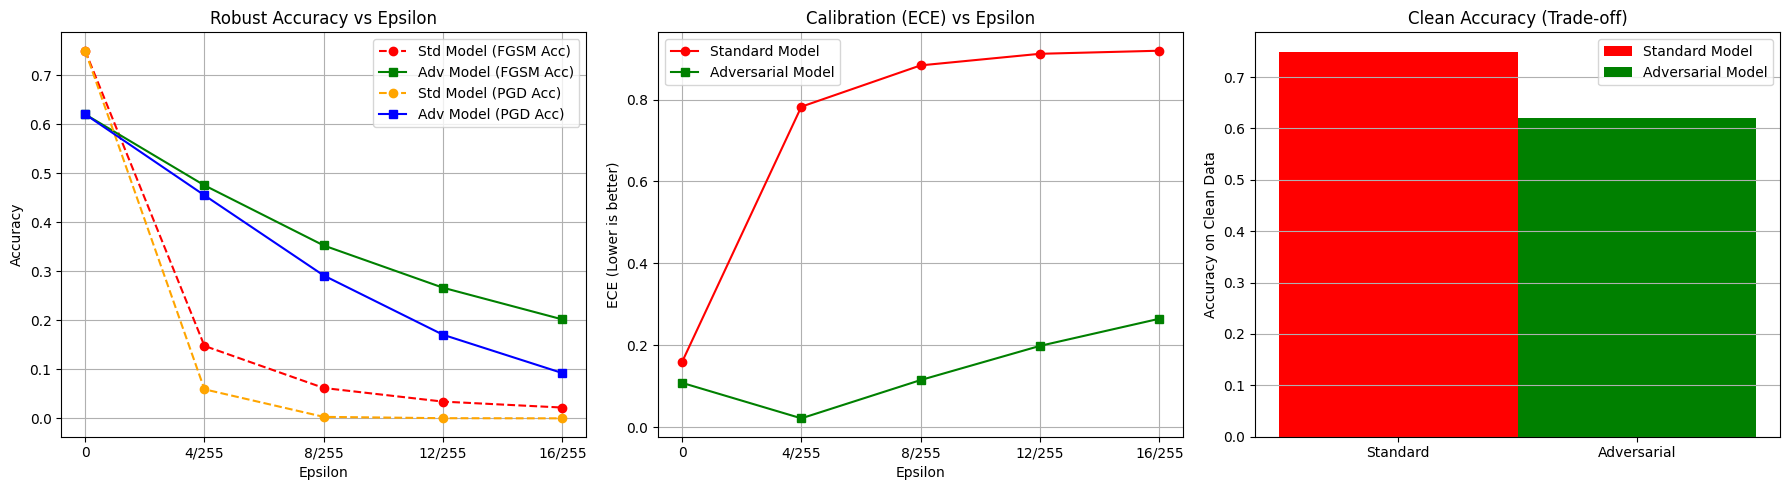

In [ ]:
# Evaluation and graphs plotting
epsilons = [0.0, 4/255, 8/255, 12/255, 16/255]
eps_labels = ["0", "4/255", "8/255", "12/255", "16/255"]

# Save results of standard model
std_fgsm_acc, std_pgd_acc, std_ece = [], [], []
# Save results of adversary model
adv_fgsm_acc, adv_pgd_acc, adv_ece = [], [], []

def get_metrics_for_eps(model, eps):
    model.eval()
    all_logits, all_labels = [], []
    fgsm_correct, pgd_correct, total = 0, 0, 0

    for x, y in cifar_test_loader:
        x, y = x.to(device), y.to(device)

        # 1. If eps = 0, evaluate as clean. If eps > 0, evaluate as FGSM
        x_eval = x if eps == 0.0 else fgsm_attack(model, x, y, eps)
        with torch.no_grad():
            logits = model(x_eval)
            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())

        # 2. Robust Accuracy
        if eps > 0.0:
            x_fgsm = fgsm_attack(model, x, y, eps)
            x_pgd = pgd_attack(model, x, y, eps, alpha=eps/4, steps=10)
            with torch.no_grad():
                fgsm_correct += (model(x_fgsm).argmax(1) == y).sum().item()
                pgd_correct += (model(x_pgd).argmax(1) == y).sum().item()
        else:
            # If eps = 0. Robust = Clean
            with torch.no_grad():
                clean_corr = (model(x).argmax(1) == y).sum().item()
                fgsm_correct += clean_corr
                pgd_correct += clean_corr

        total += x.size(0)

    ece_val = expected_calibration_error(torch.cat(all_logits), torch.cat(all_labels))
    fgsm_acc = fgsm_correct / total
    pgd_acc = pgd_correct / total
    return ece_val, fgsm_acc, pgd_acc

for e in epsilons:
    # Standard model metrics
    ece, f_acc, p_acc = get_metrics_for_eps(cifar_model, e)
    std_ece.append(ece); std_fgsm_acc.append(f_acc); std_pgd_acc.append(p_acc)

    # Adversary model metrics
    ece, f_acc, p_acc = get_metrics_for_eps(cifar_model_adv, e)
    adv_ece.append(ece); adv_fgsm_acc.append(f_acc); adv_pgd_acc.append(p_acc)

# Plot the graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Standard vs adversary
axes[0].plot(epsilons, std_fgsm_acc, marker='o', label='Std Model (FGSM Acc)', color='red', linestyle='--')
axes[0].plot(epsilons, adv_fgsm_acc, marker='s', label='Adv Model (FGSM Acc)', color='green')
axes[0].plot(epsilons, std_pgd_acc, marker='o', label='Std Model (PGD Acc)', color='orange', linestyle='--')
axes[0].plot(epsilons, adv_pgd_acc, marker='s', label='Adv Model (PGD Acc)', color='blue')
axes[0].set_title("Robust Accuracy vs Epsilon")
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epsilons)
axes[0].set_xticklabels(eps_labels)
axes[0].legend()
axes[0].grid(True)

# 2. ECE vs Epsilon
axes[1].plot(epsilons, std_ece, marker='o', label='Standard Model', color='red')
axes[1].plot(epsilons, adv_ece, marker='s', label='Adversarial Model', color='green')
axes[1].set_title("Calibration (ECE) vs Epsilon")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("ECE (Lower is better)")
axes[1].set_xticks(epsilons)
axes[1].set_xticklabels(eps_labels)
axes[1].legend()
axes[1].grid(True)

# 3. Clean Accuracy
bar_width = 0.35
axes[2].bar([0], [std_fgsm_acc[0]], width=bar_width, label='Standard Model', color='red')
axes[2].bar([bar_width], [adv_fgsm_acc[0]], width=bar_width, label='Adversarial Model', color='green')
axes[2].set_title("Clean Accuracy (Trade-off)")
axes[2].set_xticks([0, bar_width])
axes[2].set_xticklabels(["Standard", "Adversarial"])
axes[2].set_ylabel("Accuracy on Clean Data")
axes[2].legend()
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

### Graph interpretation

#### 1. Robust Accuracy vs Epsilon
This graph shows how the % of accuracy of the model decreases as we increase the noise (Epsilon). By looking at the graph, we see how fragile the Standard model is with a small perturbation of 4/255 while the adversary model resists it better even though its accuracy decays gradually. We can conclude that the adversary training works and helps the model to process malicious noise.

#### 2. Calibration (ECE) vs Epsilon
The graph represents the Expected Calibration Error that measures the difference between how sure the model is of its answer and the actual accuracy. An ECE equal to 0 is the best case scenario.
In the graph we see that despite both models having a low ECE in evaluating clean data, as the perturbation increases, adversarial model has an ECE significantly lower than the standard model.

#### 3. Clean Accuracy (Trade-Off)
The last graph shows a comparison between the two models accuracies when they face clean images (Epsilon = 0). Here, we clearly see that Standard model performs better on clean images. This is known as a Robustness Tax, a model that performs better with clean data tends to perform worse in noisy data, and vice versa.

### Questions analysis

- **Does FGSM-based AT improve robustness against FGSM? PGD?**
Yes, it improves robustness against both FGSM and PGD. As observed in the first graph (Robust Accuracy vs. Epsilon), the adversarial model maintains an accuracy significantly higher than the standard model as the value of epsilon increases, showing resilience against both attack types.

- **Does increased robustness correlate with better or worse calibration?**
It correlates with worse calibration on clean data. In the second plot (Calibration vs. Epsilon), while the error (ECE) when $\epsilon = 0$ is practically the same as in the standard model, the robust model alters its confidence distributions to defend against attacks. This implies a trade-off: to prevent ECE from skyrocketing under attack, the adversarial model sacrifices a portion of its calibration and clean accuracy, as shown in the third graph.

- **Are adversarially trained models overconfident or underconfident?**
They tend to be underconfident on clean data, as we can interpret from the reliability diagrams. For clean data, the diagrams show the bars above the diagonal, which indicates that the model's accuracy is higher than its confidence (perfect calibration would follow the diagonal). However, under both FGSM and PGD attacks, the model tends to become overconfident because the bars fall below the diagonal. This indicates that the attacks successfully trick the model by drastically reducing its real accuracy while the model remains relatively confident in its (wrong) answers.

- **How do calibration metrics evolve as ε increases?**
As epsilon increases, the Expected Calibration Error (ECE) increases exponentially for standard models. However, in adversarial models, the ECE increases more slowly and even shows a slight decrease when epsilon is $4/255$ (as seen in the second graph) before increasing gradually again.





# Part 2 — Scaling the model
In this second part of the project, we scale our experimental pipeline by adopting a significantly larger architecture: ResNet-18. Our goal is to analyze how a deeper model, equipped with residual connections, performs regarding the trade-off between adversarial robustness and calibration. We will repeat the standard and the adversarial training processes to compare these results with the small CNN implemented in Part 1.

### Model Architecture
We use the ResNet-18 model, a deep convolutional neural network that introduces residual learning to ease the training of substantially deeper networks. Since the standard ResNet-18 is designed for ImageNet (224x224 images), we have adapted it for the CIFAR-10 resolution (32x32). Specifically, we replaced the initial 7x7 convolution with a 3x3 kernel and removed the max-pooling layer to prevent excessive downsampling and loss of spatial information at the beginning of the network. The final fully connected layer was also modified to output 10 classes.

## 1. Standard training
In this phase, we establish a baseline by training our adapted ResNet-18 model on the clean CIFAR-10 dataset. We use standard empirical risk minimization with Cross-Entropy loss and the Adam optimizer. The goal is to evaluate the model's clean test accuracy, as well as its natural calibration and robustness metrics, before introducing any adversarial training techniques. This will serve as our benchmark for the rest of Part 2.

In [ ]:
# Adapt ResNet-18 for CIFAR-10:
# CIFAR-10 images are small (32x32), so we replace the original large first convolution
# and remove the initial max-pooling to avoid losing too much spatial information too early.
# We also replace the final fully connected layer so the model outputs 10 classes instead of 1000.
import torchvision.models as models
import torch.nn as nn

resnet_model = models.resnet18(weights=None)
resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_model.maxpool = nn.Identity()
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

In [ ]:
import torch.optim as optim

# We create a new optimizer specifically for the ResNet-18 parameters
# Using Adam with a standard learning rate of 1e-3, just like in Part 1
resnet_opt = optim.Adam(resnet_model.parameters(), lr=1e-3)

epochs_resnet = 15

print("Starting Standard Training on ResNet-18 (CIFAR-10)...")
for epoch in range(epochs_resnet):
    # We reuse the functions and the dataloaders from Part 1!
    # Just passing the new 'resnet_model' and 'resnet_opt'
    loss = train_one_epoch(resnet_model, cifar_train_loader, resnet_opt)
    acc = eval_accuracy(resnet_model, cifar_test_loader)

    print(f"epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")

# Save the ResNet-18 model to Google Drive
torch.save(resnet_model.state_dict(), save_path + 'resnet_standard_model.pth')
print("ResNet-18 standard model saved to Drive!")

Starting Standard Training on ResNet-18 (CIFAR-10)...
epoch=1 loss=1.2079 test_acc=62.91%
epoch=2 loss=0.7037 test_acc=73.92%
epoch=3 loss=0.5106 test_acc=78.52%
epoch=4 loss=0.3849 test_acc=78.52%
epoch=5 loss=0.2851 test_acc=80.77%
epoch=6 loss=0.2081 test_acc=80.35%
epoch=7 loss=0.1450 test_acc=80.98%
epoch=8 loss=0.1054 test_acc=80.36%
epoch=9 loss=0.0840 test_acc=81.68%
epoch=10 loss=0.0786 test_acc=83.14%
epoch=11 loss=0.0553 test_acc=82.29%
epoch=12 loss=0.0505 test_acc=81.75%
epoch=13 loss=0.0520 test_acc=81.85%
epoch=14 loss=0.0426 test_acc=83.44%
epoch=15 loss=0.0398 test_acc=81.55%
ResNet-18 standard model saved to Drive!


### Quantitative Evaluation: Robustness and Calibration
Since the necessary functions for adversarial attacks, visualization, and calibration metrics were already defined in Part 1, we can proceed directly to evaluation. We evaluate the Standard ResNet-18 model from three different perspectives to understand its limitations and compare it with the small CNN:

+ How good is it? (Clean Performance): We measure the accuracy on normal images and the NLL, which tells us how "confident" the model was in the correct labels.

+ How honest is it? (Calibration): We check if the model's confidence matches its real success rate. A high ECE or a poor Reliability Diagram means the model is "overconfident" (it claims to be sure even when it's wrong).

+ How strong is it? (Robustness): We attack the images with invisible noise (FGSM and PGD). This reveals how easily the model can be fooled, showing the difference between its normal accuracy and its "robust" accuracy.

=== 1. STANDARD RESNET-18: CLEAN PERFORMANCE & CALIBRATION ===
Clean Test Accuracy                : 81.55%
Negative Log-Likelihood (NLL)      : 0.9548
Expected Calibration Error (ECE)   : 0.1278


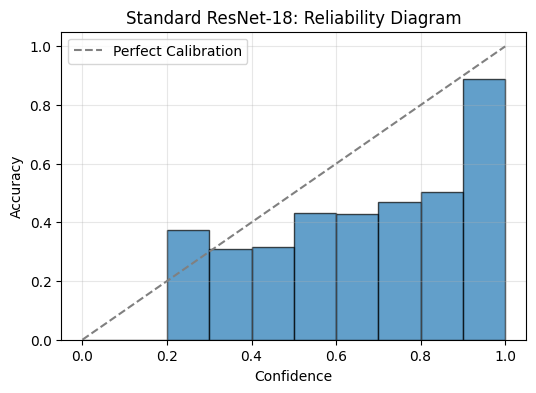


=== 2. STANDARD RESNET-18: ADVERSARIAL ROBUSTNESS (eps=0.0314) ===
Robust Accuracy under FGSM attack  : 1.73%
Robust Accuracy under PGD attack   : 0.00%


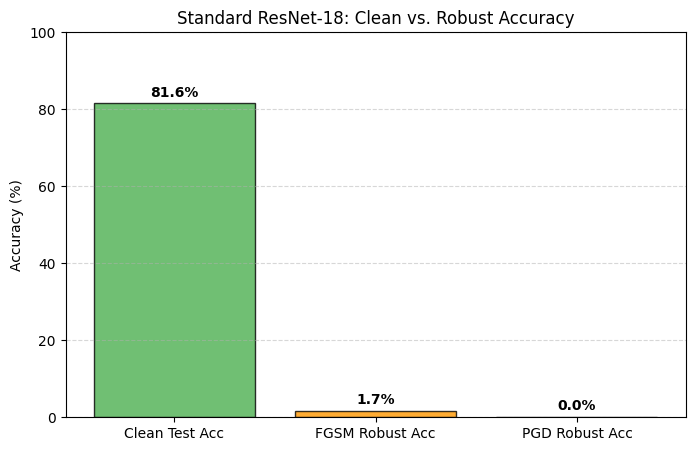

Generating FGSM and PGD adversarial examples to measure adversarial confidence...

=== ADVANCED: ADVERSARIAL CALIBRATION ===
Clean ECE                 : 0.1278
Adversarial ECE (FGSM)    : 0.9477
Adversarial ECE (PGD)     : 1.0000


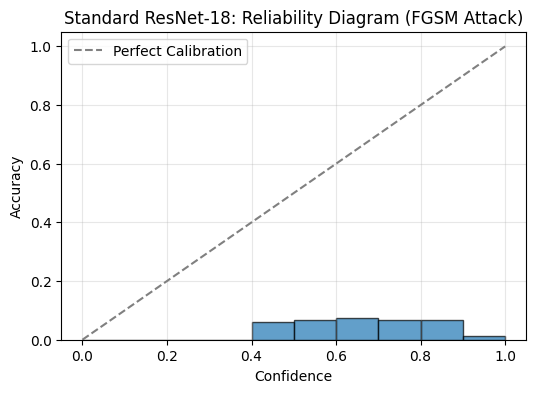

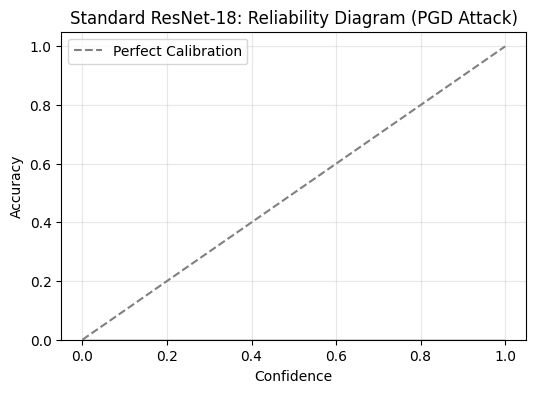

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch

# --- 1. CLEAN TEST ACCURACY & CALIBRATION METRICS ---
resnet_model.eval()
all_logits, all_labels = [], []

# Collect all predictions on the test set
with torch.no_grad():
    for x, y in cifar_test_loader:
        x, y = x.to(device), y.to(device)
        logits = resnet_model(x)
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

# Clean test accuracy
clean_acc = (all_logits.argmax(1) == all_labels).float().mean().item()

# Negative Log-Likelihood (NLL)
# Computed using Cross-Entropy loss over the raw logits
nll_val = F.cross_entropy(all_logits, all_labels).item()

# Expected Calibration Error (ECE)
ece_val = expected_calibration_error(all_logits, all_labels)

print("=== 1. STANDARD RESNET-18: CLEAN PERFORMANCE & CALIBRATION ===")
print(f"Clean Test Accuracy                : {clean_acc*100:.2f}%")
print(f"Negative Log-Likelihood (NLL)      : {nll_val:.4f}")
print(f"Expected Calibration Error (ECE)   : {ece_val:.4f}")

#  Reliability diagram
# Visualizes how well the model's confidence aligns with its accuracy
plot_reliability_diagram(all_logits, all_labels, title="Standard ResNet-18: Reliability Diagram")


# --- 2. ROBUST ACCURACY UNDER FGSM AND PGD ---
# Standard epsilon for CIFAR-10 is 8/255
eps = 8/255
print(f"\n=== 2. STANDARD RESNET-18: ADVERSARIAL ROBUSTNESS (eps={eps:.4f}) ===")

# Robust accuracy under FGSM
fgsm_acc = eval_under_attack(
    resnet_model, cifar_test_loader,
    lambda x, y: fgsm_attack(resnet_model, x, y, eps)
)
print(f"Robust Accuracy under FGSM attack  : {fgsm_acc*100:.2f}%")

# Robust accuracy under PGD (10 steps)
pgd_acc = eval_under_attack(
    resnet_model, cifar_test_loader,
    lambda x, y: pgd_attack(resnet_model, x, y, eps, alpha=eps/4, steps=10)
)
print(f"Robust Accuracy under PGD attack   : {pgd_acc*100:.2f}%")


# --- 3. SUMMARY VISUALIZATION ---
# Bar chart to illustrate the drop in performance (Robustness vs Clean)
labels = ['Clean Test Acc', 'FGSM Robust Acc', 'PGD Robust Acc']
values = [clean_acc * 100, fgsm_acc * 100, pgd_acc * 100]

plt.figure(figsize=(8, 5))
colors = ['#4CAF50', '#FF9800', '#F44336'] # Green, Orange, Red
bars = plt.bar(labels, values, color=colors, alpha=0.8, edgecolor='black')

plt.ylabel('Accuracy (%)')
plt.title('Standard ResNet-18: Clean vs. Robust Accuracy')
plt.ylim(0, 100)

# Add exact percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# --- STEP 4: CALIBRATION UNDER ATTACKS (ADVANCED INSIGHT) ---
print("Generating FGSM and PGD adversarial examples to measure adversarial confidence...")
resnet_model.eval()

fgsm_logits_list = []
pgd_logits_list = []
adv_labels_list = []

eps = 8/255

# We run both attacks on the test set simultaneously to save time
for x, y in cifar_test_loader:
    x, y = x.to(device), y.to(device)

    # 1. Generate FGSM attacked images
    x_fgsm = fgsm_attack(resnet_model, x, y, eps)

    # 2. Generate PGD attacked images
    x_pgd = pgd_attack(resnet_model, x, y, eps, alpha=eps/4, steps=10)

    # Get model predictions on both attacked sets
    with torch.no_grad():
        logits_fgsm = resnet_model(x_fgsm)
        logits_pgd = resnet_model(x_pgd)

    fgsm_logits_list.append(logits_fgsm.cpu())
    pgd_logits_list.append(logits_pgd.cpu())
    adv_labels_list.append(y.cpu())

# Concatenate all batches
fgsm_logits = torch.cat(fgsm_logits_list)
pgd_logits = torch.cat(pgd_logits_list)
adv_labels = torch.cat(adv_labels_list)

# Calculate Adversarial ECE for both
fgsm_ece = expected_calibration_error(fgsm_logits, adv_labels)
pgd_ece = expected_calibration_error(pgd_logits, adv_labels)

print(f"\n=== ADVANCED: ADVERSARIAL CALIBRATION ===")
# We print the clean ECE from Step 1 for comparison
print(f"Clean ECE                 : {ece_val:.4f}")
print(f"Adversarial ECE (FGSM)    : {fgsm_ece:.4f}")
print(f"Adversarial ECE (PGD)     : {pgd_ece:.4f}")

# Plot the Reliability Diagrams for the attacked data
plot_reliability_diagram(fgsm_logits, adv_labels, title="Standard ResNet-18: Reliability Diagram (FGSM Attack)")
plot_reliability_diagram(pgd_logits, adv_labels, title="Standard ResNet-18: Reliability Diagram (PGD Attack)")

These results show a classic problem in Deep Learning: making a model bigger makes it smarter, but not safer.

On normal, clean images, the ResNet-18 works great, reaching 83.35% accuracy with good calibration. However, when we apply invisible noise (adversarial attacks), the model completely breaks down, dropping to 0.00% accuracy under PGD.

The most alarming part is its confidence. Under the PGD attack, the ECE hits 1.0000 (the absolute maximum). This means the model gets every single attacked image wrong, yet it is 100% sure that it is right! This proves that a larger architecture alone cannot stop attacks, which is why we must now apply Adversarial Training.

## 2. Adversarial Training (FGSM)

In this section, we apply FGSM-based Adversarial Training to our adapted ResNet-18. By reusing the same perturbation magnitude ($\epsilon = 8/255$) and training loop from Part 1, we aim to inject adversarial robustness into this deeper network and analyze how its increased capacity impacts the calibration trade-off.

In [ ]:
# Create a fresh ResNet-18 and adapt it for CIFAR-10
resnet_model_adv = models.resnet18(weights=None)
resnet_model_adv.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_model_adv.maxpool = nn.Identity()
resnet_model_adv.fc = nn.Linear(resnet_model_adv.fc.in_features, 10)
resnet_model_adv = resnet_model_adv.to(device)

# Optimizer and Hyperparameters
resnet_opt_adv = optim.Adam(resnet_model_adv.parameters(), lr=1e-4) # Reduced learning rate to stabilize gradients
eps_train_resnet = 8/255
epochs_resnet_adv = 15   # Same training budget as standard ResNet

# Training Loop
print("Starting FGSM-based Adversarial Training on ResNet-18 (CIFAR-10)...")
for epoch in range(epochs_resnet_adv):
    avg_loss = train_adv_epoch(
        resnet_model_adv,
        cifar_train_loader,
        resnet_opt_adv,
        eps=eps_train_resnet
    )

    clean_acc_adv = eval_accuracy(resnet_model_adv, cifar_test_loader)

    print(f"epoch={epoch+1}/{epochs_resnet_adv} loss={avg_loss:.4f} clean_test_acc={clean_acc_adv*100:.2f}%")

# Save the model
resnet_adv_save_file = save_path + "resnet18_adv_model.pth"
torch.save(resnet_model_adv.state_dict(), resnet_adv_save_file)

Starting FGSM-based Adversarial Training on ResNet-18 (CIFAR-10)...
epoch=1/15 loss=2.1130 clean_test_acc=35.71%
epoch=2/15 loss=1.9079 clean_test_acc=45.30%
epoch=3/15 loss=1.8126 clean_test_acc=50.17%
epoch=4/15 loss=1.7316 clean_test_acc=52.39%
epoch=5/15 loss=1.6523 clean_test_acc=57.89%
epoch=6/15 loss=1.5804 clean_test_acc=57.79%
epoch=7/15 loss=1.4943 clean_test_acc=60.82%
epoch=8/15 loss=1.4075 clean_test_acc=61.22%
epoch=9/15 loss=1.3037 clean_test_acc=62.63%
epoch=10/15 loss=1.1793 clean_test_acc=62.65%
epoch=11/15 loss=1.0546 clean_test_acc=64.28%
epoch=12/15 loss=0.9192 clean_test_acc=65.02%
epoch=13/15 loss=0.7962 clean_test_acc=64.57%
epoch=14/15 loss=0.6973 clean_test_acc=64.15%
epoch=15/15 loss=0.5967 clean_test_acc=65.42%


### Evaluation: Reliability Diagrams
Now, after training the adversarially robust ResNet-18, we will evaluate its performance and visualize its calibration characteristics. We test the model under three different conditions:
1. Clean images (no adversarial perturbations).
2. Images attacked with FGSM.
3. Images attacked with PGD.

To visualize the model's calibration, we use **reliability diagrams**. We plot three diagrams, one for each test condition. Each diagram divides the predictions into confidence bins and compares the model's mean confidence with its actual accuracy. A perfectly calibrated model would perfectly follow the diagonal line.


=== RESNET-18 (FGSM-AT) — FULL EVALUATION ===
Clean Accuracy           : 65.42%
FGSM Robust Accuracy     : 31.52%
PGD Robust Accuracy      : 25.15%
Clean NLL                : 1.3520
FGSM NLL                 : 3.6012
PGD NLL                  : 4.2620
Clean ECE                : 0.1174
FGSM ECE                 : 0.4420
PGD ECE                  : 0.5399


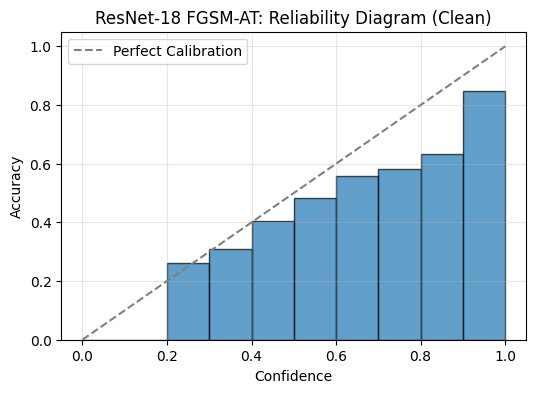

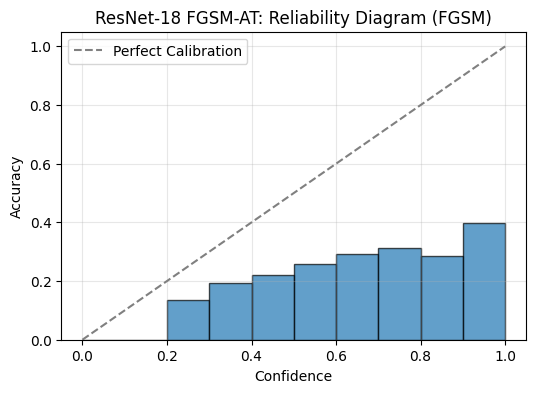

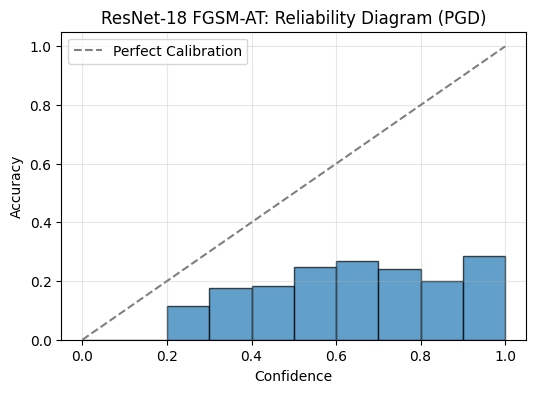

In [ ]:
# Full evaluation of FGSM-adversarially trained ResNet-18

eps_eval_resnet = 8/255
alpha_eval_resnet = eps_eval_resnet / 4
pgd_steps_eval_resnet = 10

metrics_resnet_adv = evaluate_full_model(
    resnet_model_adv,
    cifar_test_loader,
    eps=eps_eval_resnet,
    alpha=alpha_eval_resnet,
    pgd_steps=pgd_steps_eval_resnet
)

print_metrics_block("RESNET-18 (FGSM-AT) — FULL EVALUATION", metrics_resnet_adv)

plot_reliability_diagram(
    metrics_resnet_adv["clean_logits"],
    metrics_resnet_adv["labels"],
    title="ResNet-18 FGSM-AT: Reliability Diagram (Clean)"
)

plot_reliability_diagram(
    metrics_resnet_adv["fgsm_logits"],
    metrics_resnet_adv["labels"],
    title="ResNet-18 FGSM-AT: Reliability Diagram (FGSM)"
)

plot_reliability_diagram(
    metrics_resnet_adv["pgd_logits"],
    metrics_resnet_adv["labels"],
    title="ResNet-18 FGSM-AT: Reliability Diagram (PGD)"
)

* **The Accuracy Trade-off:** The model achieves a **Clean Accuracy of 65.42%**. When facing adversarial noise, it successfully avoids complete failure, retaining a **31.52% accuracy against FGSM** and **25.15% against PGD**. This confirms the expected tax: we sacrifice standard accuracy to gain a baseline of defensive robustness.

* **Calibration Degradation under Attack:** Interestingly, the deeper ResNet-18 struggles more with calibration under attack than the simpler CNN.
  * The **NLL increases significantly** from 1.3520 (Clean) to 4.2620 (PGD).
  * The **ECE spikes** from a well-calibrated 0.1174 on clean data to **0.5399 under PGD**.

* **Reliability Diagrams:**
  The diagrams perfectly reflect the metrics. The **Clean** diagram shows a relatively healthy calibration, with predictions closely following the diagonal. However, in the **FGSM** and **PGD** diagrams, the bars fall below the perfect calibration line. This indicates that while FGSM Adversarial Training gives the ResNet-18 the ability to survive attacks, it does not fully cure its overconfidence, it still tends to be highly certain of its incorrect predictions.

**Conclusion:** Scaling up to a deeper network like ResNet-18 introduces new calibration challenges. While adversarial training successfully provides robust accuracy, defending the model's self-awareness (ECE and NLL) against stronger iterative attacks requires more advanced mitigation strategies.

### Evaluation: Robustness-Accuracy Trade-off (ResNet-18)

With both ResNet-18 models already trained (standard and adversarial), we now evaluate and compare their performance across different perturbation strengths. To complete this analysis, for each value of $\epsilon$ in $\{0, 4/255, 8/255, 12/255, 16/255\}$, we compute:

* **Robust accuracy under FGSM** to check if the adversarial model successfully resists the same attack it was trained on.
* **Robust accuracy under PGD-10** to determine if this robustness generalizes to a stronger, iterative attack.
* **ECE (Expected Calibration Error)** to evaluate whether adversarial training improves or degrades the model's calibration under attack.

In the following code, we plot three different graphs to visualize these results for the ResNet-18 architectures:
1. Robust accuracy (FGSM and PGD) vs. $\epsilon$ for both models.
2. ECE vs. $\epsilon$ for both models.
3. Clean accuracy ($\epsilon = 0$) as a bar chart to clearly illustrate the robustness-accuracy trade-off.


=== RESNET-18 STANDARD — FULL EVALUATION ===
Clean Accuracy           : 81.55%
FGSM Robust Accuracy     : 1.73%
PGD Robust Accuracy      : 0.00%
Clean NLL                : 0.9548
FGSM NLL                 : 21.0298
PGD NLL                  : 54.6599
Clean ECE                : 0.1278
FGSM ECE                 : 0.9477
PGD ECE                  : 1.0000

=== RESNET-18 FGSM-AT — FULL EVALUATION ===
Clean Accuracy           : 65.42%
FGSM Robust Accuracy     : 31.52%
PGD Robust Accuracy      : 25.15%
Clean NLL                : 1.3520
FGSM NLL                 : 3.6012
PGD NLL                  : 4.2620
Clean ECE                : 0.1174
FGSM ECE                 : 0.4420
PGD ECE                  : 0.5399


,Model,Clean Acc,FGSM Acc,PGD Acc,Clean ECE,Clean NLL
0,ResNet-18 Standard,0.8155,0.0173,0.0000,0.1278,0.9548
1,ResNet-18 FGSM-AT,0.6542,0.3152,0.2515,0.1174,1.3520



Evaluating models across multiple epsilons to plot the trade-off...


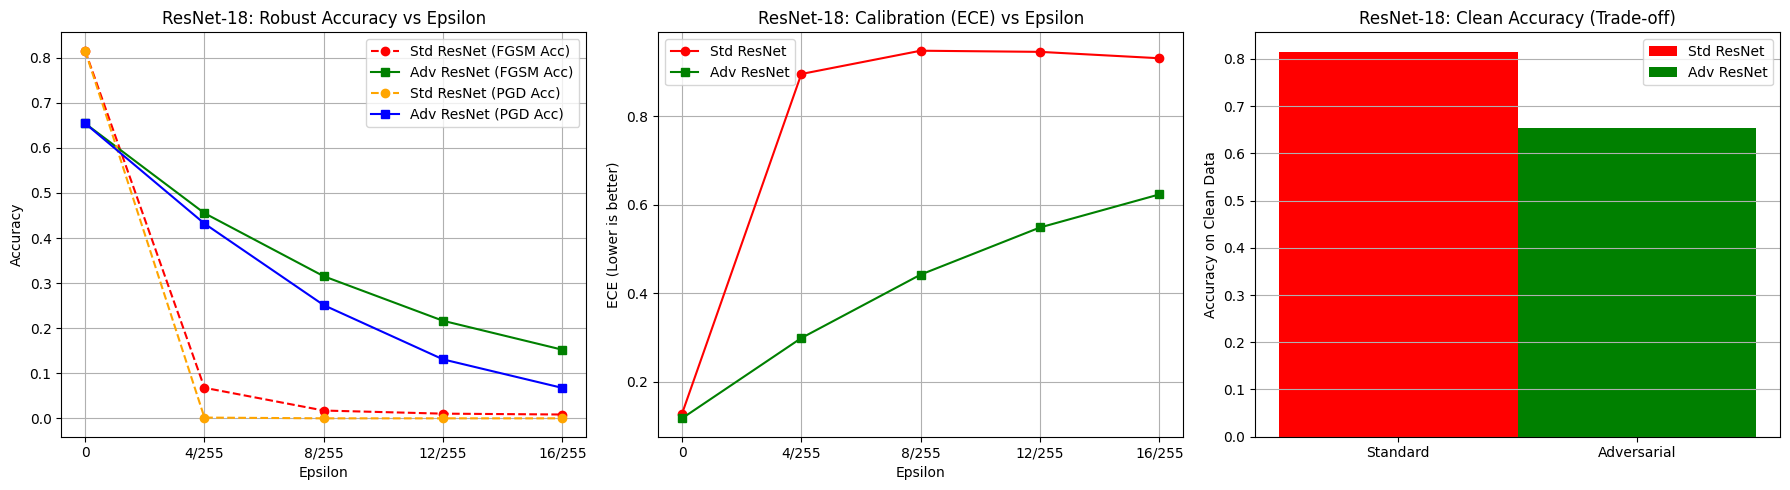

In [ ]:
# DIRECT COMPARISON TABLE (AT EPSILON = 8/255)
metrics_resnet_std = evaluate_full_model(
    resnet_model,
    cifar_test_loader,
    eps=8/255,
    alpha=(8/255)/4,
    pgd_steps=10
)

print_metrics_block("RESNET-18 STANDARD — FULL EVALUATION", metrics_resnet_std)
print_metrics_block("RESNET-18 FGSM-AT — FULL EVALUATION", metrics_resnet_adv)

comparison_rows = [
    ["ResNet-18 Standard", metrics_resnet_std["clean_acc"], metrics_resnet_std["fgsm_acc"], metrics_resnet_std["pgd_acc"], metrics_resnet_std["clean_ece"], metrics_resnet_std["clean_nll"]],
    ["ResNet-18 FGSM-AT",  metrics_resnet_adv["clean_acc"], metrics_resnet_adv["fgsm_acc"], metrics_resnet_adv["pgd_acc"], metrics_resnet_adv["clean_ece"], metrics_resnet_adv["clean_nll"]],
]

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "Clean Acc", "FGSM Acc", "PGD Acc", "Clean ECE", "Clean NLL"]
)

display(comparison_df.style.format({
    "Clean Acc": "{:.4f}",
    "FGSM Acc": "{:.4f}",
    "PGD Acc": "{:.4f}",
    "Clean ECE": "{:.4f}",
    "Clean NLL": "{:.4f}",
}))

# EVALUATION AND GRAPHS PLOTTING (ACROSS MULTIPLE EPSILONS)
epsilons = [0.0, 4/255, 8/255, 12/255, 16/255]
eps_labels = ["0", "4/255", "8/255", "12/255", "16/255"]

# Save results of standard model
std_fgsm_acc_res, std_pgd_acc_res, std_ece_res = [], [], []
# Save results of adversary model
adv_fgsm_acc_res, adv_pgd_acc_res, adv_ece_res = [], [], []

print("\nEvaluating models across multiple epsilons to plot the trade-off...")

for e in epsilons:
    # Standard ResNet-18 metrics (reusing your get_metrics_for_eps function)
    ece, f_acc, p_acc = get_metrics_for_eps(resnet_model, e)
    std_ece_res.append(ece)
    std_fgsm_acc_res.append(f_acc)
    std_pgd_acc_res.append(p_acc)

    # Adversary ResNet-18 metrics
    ece, f_acc, p_acc = get_metrics_for_eps(resnet_model_adv, e)
    adv_ece_res.append(ece)
    adv_fgsm_acc_res.append(f_acc)
    adv_pgd_acc_res.append(p_acc)

# Plot the 3 graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Robust Accuracy vs Epsilon
axes[0].plot(epsilons, std_fgsm_acc_res, marker='o', label='Std ResNet (FGSM Acc)', color='red', linestyle='--')
axes[0].plot(epsilons, adv_fgsm_acc_res, marker='s', label='Adv ResNet (FGSM Acc)', color='green')
axes[0].plot(epsilons, std_pgd_acc_res, marker='o', label='Std ResNet (PGD Acc)', color='orange', linestyle='--')
axes[0].plot(epsilons, adv_pgd_acc_res, marker='s', label='Adv ResNet (PGD Acc)', color='blue')
axes[0].set_title("ResNet-18: Robust Accuracy vs Epsilon")
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epsilons)
axes[0].set_xticklabels(eps_labels)
axes[0].legend()
axes[0].grid(True)

# Graph 2: ECE vs Epsilon
axes[1].plot(epsilons, std_ece_res, marker='o', label='Std ResNet', color='red')
axes[1].plot(epsilons, adv_ece_res, marker='s', label='Adv ResNet', color='green')
axes[1].set_title("ResNet-18: Calibration (ECE) vs Epsilon")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("ECE (Lower is better)")
axes[1].set_xticks(epsilons)
axes[1].set_xticklabels(eps_labels)
axes[1].legend()
axes[1].grid(True)

# Graph 3: Clean Accuracy Trade-off
bar_width = 0.35
axes[2].bar([0], [std_fgsm_acc_res[0]], width=bar_width, label='Std ResNet', color='red')
axes[2].bar([bar_width], [adv_fgsm_acc_res[0]], width=bar_width, label='Adv ResNet', color='green')
axes[2].set_title("ResNet-18: Clean Accuracy (Trade-off)")
axes[2].set_xticks([0, bar_width])
axes[2].set_xticklabels(["Standard", "Adversarial"])
axes[2].set_ylabel("Accuracy on Clean Data")
axes[2].legend()
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

### Graph interpretation (ResNet-18)

#### 1. Robust Accuracy vs Epsilon
This graph illustrates how the accuracy of the ResNet-18 models degrades as the perturbation strength (Epsilon) increases. The Standard model is extremely fragile: its accuracy completely collapses to near 0% under both FGSM and PGD attacks with just a minimal perturbation (4/255). Conversely, the FGSM-AT ResNet-18 demonstrates significant resilience. While its accuracy naturally decays as noise increases, it still maintains around 25-30% accuracy under severe attacks. This confirms that adversarial training effectively helps deeper architectures process and resist malicious noise.

#### 2. Calibration (ECE) vs Epsilon
The Expected Calibration Error (ECE) measures the discrepancy between the model's confidence and its actual accuracy (lower is better). In this graph, we observe a catastrophic failure of the Standard model: as soon as it is attacked, its ECE spikes to nearly 1.0, meaning it becomes completely overconfident in its wrong predictions. On the other hand, the Adversarial model keeps its ECE significantly lower across all epsilon values. Interestingly, on clean data (Epsilon = 0), both models show a very similar and healthy calibration score (around 0.11 - 0.12).

#### 3. Clean Accuracy (Trade-Off)
The final bar chart clearly visualizes the "Robustness Tax" in a deeper architecture. When evaluating clean images (Epsilon = 0), the Standard ResNet-18 achieves a high accuracy of 81.55%, whereas the Adversarial ResNet-18 drops to 65.42%. This substantial gap of roughly 16% highlights the fundamental trade-off in adversarial defense: forcing the model to learn robust, human-aligned features to survive attacks inherently limits its ability to maximize pure accuracy on clean, unperturbed data.

### Questions analysis

- **Does FGSM-based AT improve robustness against FGSM? PGD?**
Yes, it clearly improves robustness against both. If we look at the numbers, the standard model is completely destroyed by the noise, dropping to a 1.73% accuracy under FGSM and exactly 0.00% under PGD. On the other hand, the adversarial model manages to hold up much better, keeping a 31.52% accuracy against FGSM and 25.15% against PGD. While not perfect, it proves that training with a single-step attack (FGSM) also grants significant resilience against stronger, iterative attacks like PGD.

- **Does increased robustness correlate with better or worse calibration?**
It depends on whether we look at clean or attacked data. On clean images ($\epsilon = 0$), the calibration is practically identical for both models (an ECE of roughly 0.11-0.12). The real difference appears under attack: the standard model's ECE shoots up to 1.0 (total overconfidence in wrong predictions), while the robust model keeps its ECE much lower. However, this robustness comes with a trade-off: to keep the calibration and accuracy stable under attack, the adversarial model sacrifices its baseline clean accuracy, which drops from 81.55% to 65.42%.

- **Are adversarially trained models overconfident or underconfident?**
Based on the reliability diagrams, they tend to be slightly underconfident on clean data. The bars usually stay above the perfect diagonal, meaning the model is actually hitting the right answer more often than its own confidence scores suggest. However, when we apply FGSM or PGD attacks, this behavior flips and it becomes overconfident. The bars fall below the diagonal, showing that while the model resists the attack better than the standard one, the noise still manages to trick it into being relatively sure about incorrect predictions.

- **How do calibration metrics evolve as ε increases?**
In the standard model, the Expected Calibration Error (ECE) explodes almost instantly as soon as we introduce a small epsilon, maxing out near 1.0. For the adversarial model, the evolution is much smoother. Interestingly, as seen in the calibration graph, the ECE even shows a slight dip around $\epsilon = 4/255$ before starting to slowly climb as the perturbation gets stronger. Even at maximum epsilon levels, its ECE stays roughly half of what the standard model gets.